In [1]:
from pathlib import Path
import numpy as np

dataset_path = Path("datasets/base_params_300_periods_linear")

str_jpc_config = (dataset_path / "jpc_config.txt").read_text()
str_quantum_parameters = (dataset_path / "quantum_parameters.txt").read_text()
str_encoding = (dataset_path / "encoding.txt").read_text()

print(str_jpc_config)
print(str_quantum_parameters)
print(str_encoding)

JPCConfig(
    DIM_A=10,
    DIM_B=10,
    OMEGA_A=10000.0,
    OMEGA_B=9000.0,
    KAPPA_A=17,
    KAPPA_B=21,
    K_AA=0.1,
    K_BB=0.1,
    K_AB=0.05,
    DRIVE_DURATION=0.04,
    MEASURE_RESOLUTION=10,
    SIMULATION_RESOLUTION=10
)

QuantumParameters(
    g_conv=900,
    g_sq=180,
    epsilon_a=170,
    epsilon_b=170,
    delta_a=0,
    delta_b=0
)

Encoding(
    encoding_parameters=('g_sq',),
    encoding_function=Linear()
)



In [2]:
X = np.load(dataset_path / "X.npy")
Y = np.load(dataset_path / "Y.npy")

X.shape, Y.shape

((30, 80), (30, 80, 1))

In [3]:
F_quad = np.load(dataset_path / "f_quad.npy")
F_quad_poly = np.load(dataset_path / "f_quad_poly.npy")
F_probas = np.load(dataset_path / "f_probas.npy")

F_quad.shape, F_quad_poly.shape, F_probas.shape

((30, 80, 40), (30, 80, 140), (30, 80, 40))

In [4]:
nb_batches_train = 20

X_train, X_test = X[:nb_batches_train], X[nb_batches_train:]
Y_train, Y_test = Y[:nb_batches_train], Y[nb_batches_train:].reshape(-1, Y.shape[-1])

F_train_quad, F_test_quad = F_quad[:nb_batches_train], F_quad[nb_batches_train:].reshape(-1, F_quad.shape[-1])
F_train_quad_poly, F_test_quad_poly = F_quad_poly[:nb_batches_train], F_quad_poly[nb_batches_train:].reshape(-1, F_quad_poly.shape[-1])
F_train_probas, F_test_probas = F_probas[:nb_batches_train], F_probas[nb_batches_train:].reshape(-1, F_probas.shape[-1])

F_train_quad.shape, F_train_quad_poly.shape, F_train_probas.shape

((20, 80, 40), (20, 80, 140), (20, 80, 40))

In [5]:
from lab.config.neural_networks import linear
from zeroth import first_order

linear.summary()

neural_network_quad = first_order.FirstOrderNeuralNetwork(config=linear,
                                                          input_dim=F_quad.shape[-1],
                                                          output_dim=2)

neural_network_quad_poly = first_order.FirstOrderNeuralNetwork(config=linear,
                                                               input_dim=F_quad_poly.shape[-1],
                                                               output_dim=2)

neural_network_probas = first_order.FirstOrderNeuralNetwork(linear,
                                                            input_dim=F_probas.shape[-1],
                                                            output_dim=2)


NeuralNetworkConfig(
    name='Linear',
    hidden_dims=[],
    activations=[
        Softmax()
    ]
)


In [6]:
optimizer_config = first_order.FirstOrderAdamConfig(learning_rate=0.01,
                                                    beta1=0.99,
                                                    beta2=0.999,
                                                    epsilon=1e-8)

optimizer_quad = optimizer_config.instantiate()
optimizer_quad_poly = optimizer_config.instantiate()
optimizer_probas = optimizer_config.instantiate()

In [7]:
from zeroth.losses import CrossEntropy

loss = CrossEntropy()

def train_step(_F_quad: np.ndarray, _F_quad_poly: np.ndarray, _F_probas: np.ndarray, _Y: np.ndarray) -> tuple[float, float, float]:
    loss_quad = optimizer_quad.do_descent(neural_network=neural_network_quad,
                                          loss=loss,
                                          X=_F_quad,
                                          Y_true=_Y)

    loss_quad_poly = optimizer_quad_poly.do_descent(neural_network=neural_network_quad_poly,
                                                    loss=loss,
                                                    X=_F_quad_poly,
                                                    Y_true=_Y)

    loss_quad_probas = optimizer_probas.do_descent(neural_network=neural_network_probas,
                                                   loss=loss,
                                                   X=_F_probas,
                                                   Y_true=_Y)

    return loss_quad, loss_quad_poly, loss_quad_probas

X_train = X_train.reshape(-1)

nb_epochs = 100

losses = np.zeros((3, nb_epochs * nb_batches_train))

for epoch in range(nb_epochs):
    for i in range(nb_batches_train):
        batch_loss = train_step(_F_quad=F_train_quad[i],
                                _F_quad_poly=F_train_quad_poly[i],
                                _F_probas=F_train_probas[i],
                                _Y=Y_train[i])
        losses[:, epoch * nb_batches_train + i] = batch_loss

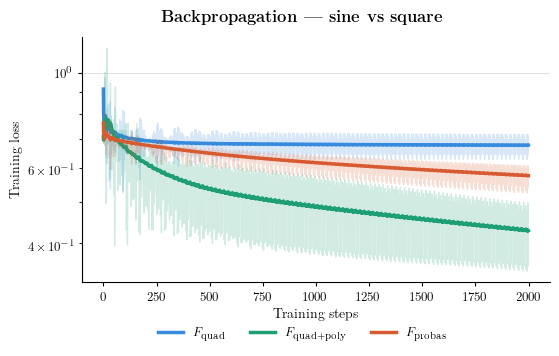

In [8]:
from zeroth.plot_losses import set_style, format_ax, smooth_curve
import matplotlib.pyplot as plt
import numpy as np

set_style()

smooth_fraction = 0.1
labels = [
    r"$F_{\mathrm{quad}}$",
    r"$F_{\mathrm{quad+poly}}$",
    r"$F_{\mathrm{probas}}$",
]

configs = [
    (losses[0],      '#378ADD',  r'$F_{\mathrm{quad}}$'),
    (losses[1], '#1D9E75', r'$F_{\mathrm{quad+poly}}$'),
    (losses[2],    '#D85A30',  r'$F_{\mathrm{probas}}$'),
]

colors  = ["#378ADD", "#1D9E75", "#D85A30"]

fig, ax = plt.subplots(figsize=(5.5, 3.5))

for data, color, label in configs:
    window = int(len(data) * smooth_fraction)

    ax.plot(data, alpha=0.2, linewidth=1.0, color=color)
    smooth = smooth_curve(data, window)
    ax.plot(smooth, label=label, linewidth=2.5, color=color)
# for data, color, ls, label in configs:
#     kde = gaussian_kde(data)
#     ax.plot(x, kde(x), color=color, ls=ls, lw=2, label=label)
#     ax.fill_between(x, kde(x), alpha=0.08, color=color)

format_ax(ax)
ax.set_xlabel("Training steps")
ax.set_ylabel("Training loss")
fig.suptitle(r"\textbf{Backpropagation — sine vs square}",
             fontweight='bold', fontsize=12)

handles, labels_leg = ax.get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, 0), frameon=False, fontsize=9)

plt.subplots_adjust(left=0.1, right=0.95, top=0.9, bottom=0.2)
plt.show()

In [9]:
Y_pred_quad = neural_network_quad(F_test_quad)
Y_pred_quad_poly = neural_network_quad_poly(F_test_quad_poly)
Y_pred_probas = neural_network_probas(F_test_probas)

Y_pred_quad.shape, Y_test.shape

((800, 2), (800, 1))

In [10]:
Y_pred_01_quad = np.argmax(Y_pred_quad, axis=1)
acc_quad = np.mean(Y_pred_01_quad == Y_test[:, 0])
print(f"Accuracy quadratures = {acc_quad * 1e2} %")

Y_pred_01_quad_poly = np.argmax(Y_pred_quad_poly, axis=1)
acc_quad_poly = np.mean(Y_pred_01_quad_poly == Y_test[:, 0])
print(f"Accuracy quadratures poly = {acc_quad_poly * 1e2} %")

Y_pred_01_probas = np.argmax(Y_pred_probas, axis=1)
acc_probas = np.mean(Y_pred_01_probas == Y_test[:, 0])
print(f"Accuracy probas = {acc_probas * 1e2} %")
np.mean(Y_pred_01_quad)

Accuracy quadratures = 43.5 %
Accuracy quadratures poly = 91.375 %
Accuracy probas = 86.625 %


np.float64(0.22)

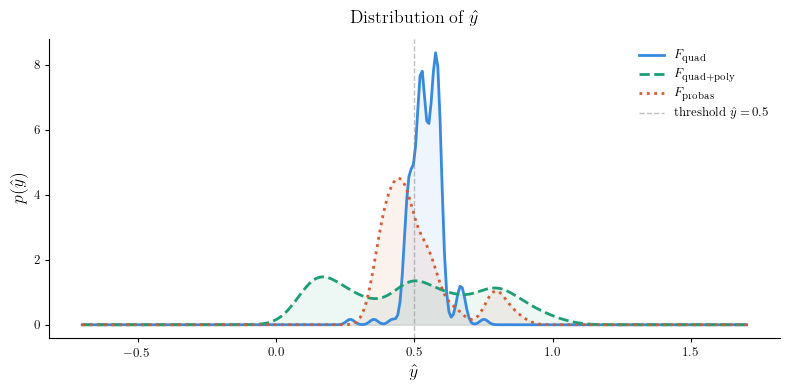

In [11]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
mask = Y_test[:, 0] == 1
x = np.linspace(-0.7, 1.7, 300)

configs = [
    (Y_pred_quad[:, 0],      '#378ADD', '-',  r'$F_{\mathrm{quad}}$'),
    (Y_pred_quad_poly[:, 0], '#1D9E75', '--', r'$F_{\mathrm{quad+poly}}$'),
    (Y_pred_probas[:, 0],    '#D85A30', ':',  r'$F_{\mathrm{probas}}$'),
]

for data, color, ls, label in configs:
    kde = gaussian_kde(data)
    ax.plot(x, kde(x), color=color, ls=ls, lw=2, label=label)
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

ax.set_title(r"Distribution of $\hat{y}$",
             fontsize=13, pad=12)
ax.axvline(0.5, color='gray', lw=1, ls='--', alpha=0.5,
           label=r'threshold $\hat{y}=0.5$')
ax.set_xlabel(r"$\hat{y}$", fontsize=13)
ax.set_ylabel(r"$p(\hat{y})$", fontsize=13)
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

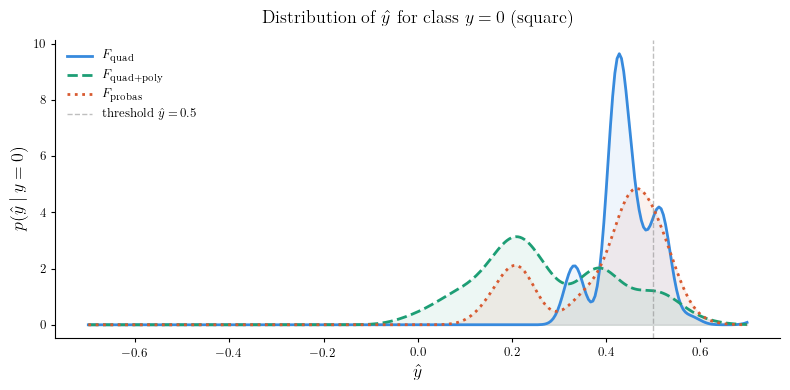

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
mask = Y_test[:, 0] == 0
x = np.linspace(-0.7, 0.7, 300)

configs = [
    (Y_pred_quad[mask, 1],      '#378ADD', '-',  r'$F_{\mathrm{quad}}$'),
    (Y_pred_quad_poly[mask, 1], '#1D9E75', '--', r'$F_{\mathrm{quad+poly}}$'),
    (Y_pred_probas[mask, 1],    '#D85A30', ':',  r'$F_{\mathrm{probas}}$'),
]

for data, color, ls, label in configs:
    kde = gaussian_kde(data)
    ax.plot(x, kde(x), color=color, ls=ls, lw=2, label=label)
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

ax.set_title(r"Distribution of $\hat{y}$ for class $y=0$ (square)",
             fontsize=13, pad=12)
ax.axvline(0.5, color='gray', lw=1, ls='--', alpha=0.5,
           label=r'threshold $\hat{y}=0.5$')
ax.set_xlabel(r"$\hat{y}$", fontsize=13)
ax.set_ylabel(r"$p(\hat{y} \mid y=0)$", fontsize=13)
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

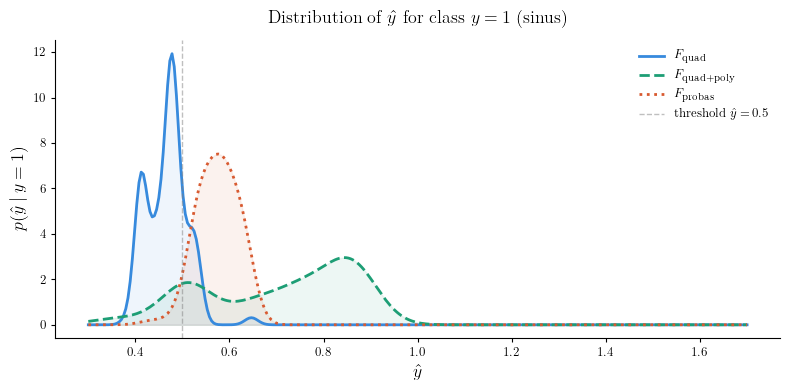

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
mask = Y_test[:, 0] == 1
x = np.linspace(0.3, 1.7, 300)

configs = [
    (Y_pred_quad[mask, 1],      '#378ADD', '-',  r'$F_{\mathrm{quad}}$'),
    (Y_pred_quad_poly[mask, 1], '#1D9E75', '--', r'$F_{\mathrm{quad+poly}}$'),
    (Y_pred_probas[mask, 1],    '#D85A30', ':',  r'$F_{\mathrm{probas}}$'),
]

for data, color, ls, label in configs:
    kde = gaussian_kde(data)
    ax.plot(x, kde(x), color=color, ls=ls, lw=2, label=label)
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

ax.set_title(r"Distribution of $\hat{y}$ for class $y=1$ (sinus)",
             fontsize=13, pad=12)
ax.axvline(0.5, color='gray', lw=1, ls='--', alpha=0.5,
           label=r'threshold $\hat{y}=0.5$')
ax.set_xlabel(r"$\hat{y}$", fontsize=13)
ax.set_ylabel(r"$p(\hat{y} \mid y=1)$", fontsize=13)
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()